In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, regularizers, optimizers, losses, metrics, models, callbacks
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from typing import Dict, Tuple
from concurrent.futures import ThreadPoolExecutor

## Importing Dataset

In [2]:
data = tf.keras.datasets.mnist.load_data()
display(data)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [3]:
(X_train, y_train), (X_test, y_test) = data
X_train = X_train.reshape(-1, 28 * 28).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28 * 28).astype('float32') / 255.0

Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

X_train, X_val, Y_train, Y_val = train_test_split(
    X_train,
    Y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

## Model Architecture

In [4]:
class Model:
    def __init__(self,
                 input_shape: Tuple[int, ...] = (28 * 28,),
                 hidden_activation: str = 'relu',
                 learning_rate: float = 0.001,
                 reg_type: str = None,
                 regularization: float = 0.01,
                 n_hidden: int = 7,
                 n_hidden_neurons: Dict[int, int] = None,
                 epochs: int = 100,
                 batch_size: int = 128,
                 validation_split: float = 0.2):
        if n_hidden_neurons is None:
            n_hidden_neurons = {i + 1: 8 for i in range(n_hidden)}
        self.input_shape = input_shape
        self.hidden_activation = hidden_activation
        self.learning_rate = learning_rate
        self.reg_type = reg_type
        self.regularization = regularization
        self.n_hidden = n_hidden
        self.n_hidden_neurons = n_hidden_neurons
        self.epochs = epochs
        self.batch_size = batch_size
        self.validation_split = validation_split
        self.model = self.build_model()
        self.history = None

    def summary(self):
        if self.model:
            self.model.summary()
        else:
            print("Model has not been built yet.")

    def regularizer(self):
        if self.reg_type == 'l1':
            return regularizers.l1(self.regularization)
        elif self.reg_type == 'l2':
            return regularizers.l2(self.regularization)
        elif self.reg_type is None:
            return None
        elif self.reg_type == 'l1_l2':
            return regularizers.l1_l2(l1=self.regularization, l2=self.regularization)
        else:
            raise ValueError("Invalid regularization type. Choose 'l1', 'l2', 'l1_l2', or None.")

    def build_model(self):
        model = models.Sequential()
        model.add(layers.Input(shape=self.input_shape))
        for i in range(1, self.n_hidden + 1):
            units = self.n_hidden_neurons.get(i, 8)
            model.add(
                layers.Dense(
                    units,
                    activation=self.hidden_activation,
                    kernel_regularizer=self.regularizer(),
                )
            )
        model.add(layers.Dense(10, activation='softmax'))

        optimizer = optimizers.Adam(learning_rate=self.learning_rate)
        model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
        return model

    def train_model(self, X_train, y_train, X_val, y_val, device_name: str = None):
        early_stopping = callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
        )
        assert self.model is not None
        fit_kwargs = dict(
            x=X_train,
            y=y_train,
            validation_data=(X_val, y_val),
            epochs=self.epochs,
            batch_size=self.batch_size,
            callbacks=[early_stopping],
            verbose=2,
        )
        if device_name:
            with tf.device(device_name):
                self.history = self.model.fit(**fit_kwargs)
        else:
            self.history = self.model.fit(**fit_kwargs)
        return self.history

    def prune(self, prune_rate: float):
        pruned_model = models.clone_model(self.model)
        pruned_model.set_weights(self.model.get_weights())
        total_weights = 0
        zero_weights = 0
        for layer in pruned_model.layers:
            if isinstance(layer, layers.Dense):
                layer_weights = layer.get_weights()
                if len(layer_weights) > 0:
                    w = layer_weights[0]
                    b = layer_weights[1] if len(layer_weights) > 1 else None
                    if prune_rate > 0:
                        threshold = np.percentile(np.abs(w), prune_rate * 100)
                        mask = np.abs(w) >= threshold
                        w_pruned = w * mask
                    else:
                        w_pruned = w
                    if b is not None:
                        layer.set_weights([w_pruned, b])
                    else:
                        layer.set_weights([w_pruned])
                    total_weights += w.size
                    zero_weights += np.sum(w_pruned == 0)
        pruned_model.compile(
            optimizer=optimizers.Adam(learning_rate=self.learning_rate),
            loss='categorical_crossentropy',
            metrics=['accuracy'],
        )
        sparsity = zero_weights / total_weights if total_weights > 0 else 0.0
        return pruned_model, sparsity

    def plot_history(self):
        if self.history is None:
            print("No training history found. Please train the model first.")
            return

        history = self.history
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(history.history['loss'], label='Training Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.title('Loss Over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(history.history['accuracy'], label='Training Accuracy')
        plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
        plt.title('Accuracy Over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()

        plt.tight_layout()
        plt.show()

    def plot_confusion_matrix(self, X_test, y_test):
        y_pred = self.model.predict(X_test, verbose=0).argmax(axis=1)
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.xlabel('Predicted label')
        plt.ylabel('True label')
        plt.title('Confusion Matrix')
        plt.show()

    def evaluate_model(self, X_test, y_test):
        y_pred = self.model.predict(X_test, verbose=0).argmax(axis=1)
        accuracy = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, zero_division=0)
        print(f"Accuracy: {accuracy:.4f}")
        print("Classification Report:")
        print(report)

    def plot_decision_boundary(self, X, y):
        print("Decision boundary plotting is not meaningful for MNIST-classification data.")


## Pruning Specifications and Model Comparison

,label,prune_rate,sparsity,total_params,nonzero_params,loss,accuracy
0,Pruned 30%,30%,30.0,439978,307011,2.296546,0.1158
1,Pruned 50%,50%,50.0,439978,219296,2.299931,0.1102
2,Pruned 40%,40%,40.0,439978,263155,2.299040,0.1080
3,Baseline (0%),0%,0.0,439978,438592,2.294670,0.1066
4,Pruned 20%,20%,20.0,439978,350871,2.295023,0.0985


/tmp/ipykernel_572/2078416885.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='prune_rate', y='accuracy', data=results_df, ax=axes[0], palette='Blues_d')
/tmp/ipykernel_572/2078416885.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='prune_rate', y='loss', data=results_df, ax=axes[1], palette='Reds_d')
/tmp/ipykernel_572/2078416885.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='prune_rate', y='nonzero_params', data=results_df, ax=axes[2], palette='Greens_d')


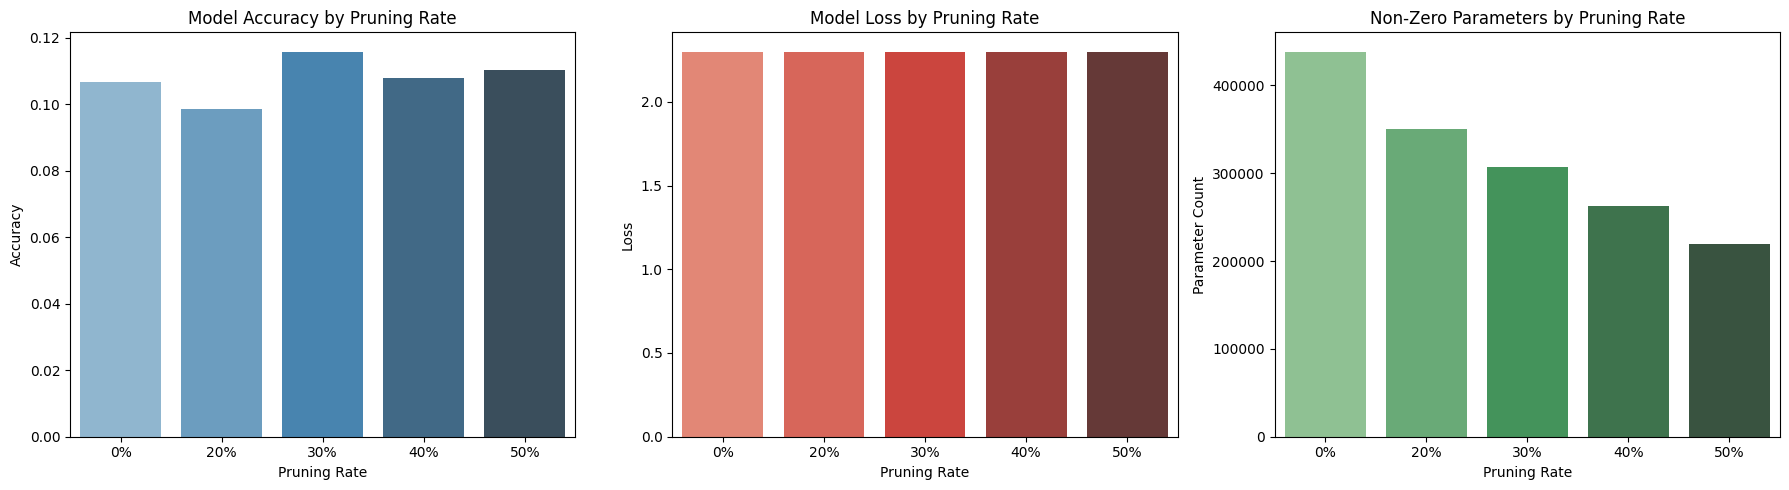

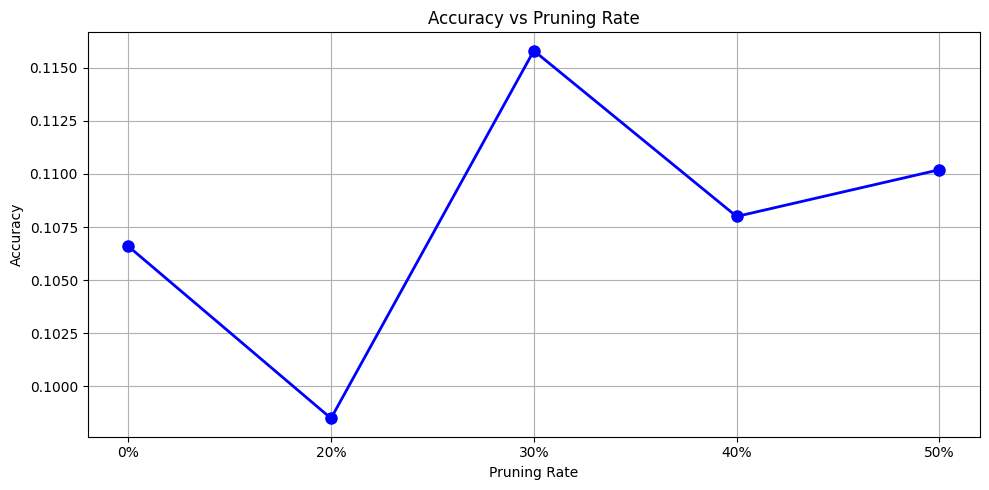

In [5]:
deep_neurons = {
    1: 128,
    2: 256,
    3: 512,
    4: 256,
    5: 128,
    6: 64,
    7: 32,
}

base_model = Model(
    input_shape=(28 * 28,),
    hidden_activation='relu',
    learning_rate=0.001,
    reg_type=None,
    regularization=0.01,
    n_hidden=7,
    n_hidden_neurons=deep_neurons,
    epochs=100,
    batch_size=128,
)

def build_prune_specs():
    rates = [0.0, 0.2, 0.3, 0.4, 0.5]
    specs = []
    for rate in rates:
        label = "Baseline (0%)" if rate == 0.0 else f"Pruned {int(rate * 100)}%"
        specs.append({
            'label': label,
            'prune_rate': rate,
            'kwargs': {
                'input_shape': (28 * 28,),
                'hidden_activation': 'relu',
                'learning_rate': 0.001,
                'reg_type': None,
                'regularization': 0.01,
                'epochs': 100,
                'batch_size': 128,
                'n_hidden': 7,
                'n_hidden_neurons': deep_neurons,
            },
        })
    return specs

def evaluate_prune_spec(spec, model_obj, X_test, Y_test):
    rate = spec['prune_rate']
    pruned_model, sparsity = model_obj.prune(rate)
    loss, accuracy = pruned_model.evaluate(X_test, Y_test, verbose=0)
    total_params = sum(w.size for w in pruned_model.get_weights())
    nonzero_params = sum(np.count_nonzero(w) for w in pruned_model.get_weights())
    return {
        'label': spec['label'],
        'prune_rate': f"{int(rate * 100)}%",
        'sparsity': round(sparsity * 100, 2),
        'total_params': total_params,
        'nonzero_params': nonzero_params,
        'loss': loss,
        'accuracy': accuracy,
        'model': pruned_model,
    }

specs = build_prune_specs()
results = [evaluate_prune_spec(spec, base_model, X_test, Y_test) for spec in specs]

results_df = pd.DataFrame([
    {key: value for key, value in result.items() if key != 'model'} for result in results
])

display(results_df.sort_values('accuracy', ascending=False).reset_index(drop=True))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x='prune_rate', y='accuracy', data=results_df, ax=axes[0], palette='Blues_d')
axes[0].set_title('Model Accuracy by Pruning Rate')
axes[0].set_xlabel('Pruning Rate')
axes[0].set_ylabel('Accuracy')

sns.barplot(x='prune_rate', y='loss', data=results_df, ax=axes[1], palette='Reds_d')
axes[1].set_title('Model Loss by Pruning Rate')
axes[1].set_xlabel('Pruning Rate')
axes[1].set_ylabel('Loss')

sns.barplot(x='prune_rate', y='nonzero_params', data=results_df, ax=axes[2], palette='Greens_d')
axes[2].set_title('Non-Zero Parameters by Pruning Rate')
axes[2].set_xlabel('Pruning Rate')
axes[2].set_ylabel('Parameter Count')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(results_df['prune_rate'], results_df['accuracy'], marker='o', linewidth=2, markersize=8, color='b')
plt.title('Accuracy vs Pruning Rate')
plt.xlabel('Pruning Rate')
plt.ylabel('Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()